# **Задача 2**

Цех N3 выпускает продукцию в виде трех изделий A, B и C **в одинаковом количестве**.  
Для изготовления каждого изделия может использоваться одна из групп технологического оборудования.  
Расход продукта Y на одно изделие приведен в табл. 1, временные параметры и фонды рабочего времени – в табл. 2.

**Таблица 1 – Расход продукта Y, ед.**

| Группа | A   | B   | C   |
|--------|-----|-----|-----|
| 1      | 0.006 | 0.006 | –   |
| 2      | 0.006 | –    | 0.001 |
| 3      | –    | 0.006 | 0.002 |

**Таблица 2 – Время изготовления (мин) и фонд времени (часы)**

| Группа | A, мин | B, мин | C, мин | Фонд времени, ч |
|--------|--------|--------|--------|-----------------|
| 1      | 10     | 9      | –      | 1050            |
| 2      | 5      | –      | 15     | 1120            |
| 3      | –      | 9      | 10     | 1300            |

Доступное количество продукта Y за квартал равно максимальному выпуску, полученному в задаче 1:  
`Y_available = 58.2261` ед.

Требуется:
1. Спланировать работу оборудования (определить, сколько изделий каждого типа и на какой группе выпускать), чтобы общее количество A, B, C было одинаковым и максимальным.
2. Выяснить, есть ли в решении полностью загруженная группа оборудования (ограничение по времени выполняется как равенство).
3. Если такая группа есть – исследовать влияние изменения её фонда времени на структуру решения (увеличение и уменьшение). Если нет – предварительно увеличить `Y_available` до появления полностью загруженной группы, затем выполнить п. 2.



## **Математическая модель**

**Переменные** (непрерывные, неотрицательные):
- `a1, a2` – количество изделий A, изготовленных на группе 1 и группе 2 соответственно
- `b1, b3` – количество изделий B, изготовленных на группе 1 и группе 3
- `c2, c3` – количество изделий C, изготовленных на группе 2 и группе 3

**Ограничения**

1. Одинаковое количество каждого изделия:
- a1 + a2 = b1 + b3 = c2 + c3 = x, где x – искомое количество каждого вида
- В линейной форме: a1 + a2 – b1 – b3 = 0, a1 + a2 – c2 – c3 = 0

2. Ограничения по фонду рабочего времени (в минутах):

- 10*a1 + 9*b1 <= 1050*60 = 63000
- 5*a2 + 15*c2 <= 1120*60 = 67200
- 9*b3 + 10*c3 <= 1300*60 = 78000

3. Ограничение по расходу продукта Y:

0.006*(a1 + a2 + b1 + b3) + 0.001*c2 + 0.002*c3 ≤ Y = 58.2261.

Целевая функция – максимизировать x = a1 + a2:
max (a1 + a2).

Все переменные >= 0

Задача линейного программирования. Будем решать ее симплекс‑методом



Количество каждого изделия x = 4478.9308
Распределение A:  группа1 = 4475.72, группа2 = 3.21
Распределение B:  группа1 = 2026.97, группа3 = 2451.96
Распределение C:  группа2 = 4478.93, группа3 = 0.00
Расход продукта Y: 58.2261 (лимит 58.2261)
Загрузка группы 1: 63000.00 / 63000 мин (1050.00 / 1050 ч)
Загрузка группы 2: 67200.00 / 67200 мин (1120.00 / 1120 ч)
Загрузка группы 3: 22067.61 / 78000 мин (367.79 / 1300 ч)

Полностью загруженные ресурсы: ['Группа 1', 'Группа 2', 'Расход Y']

Параметрический анализ для Группа 1


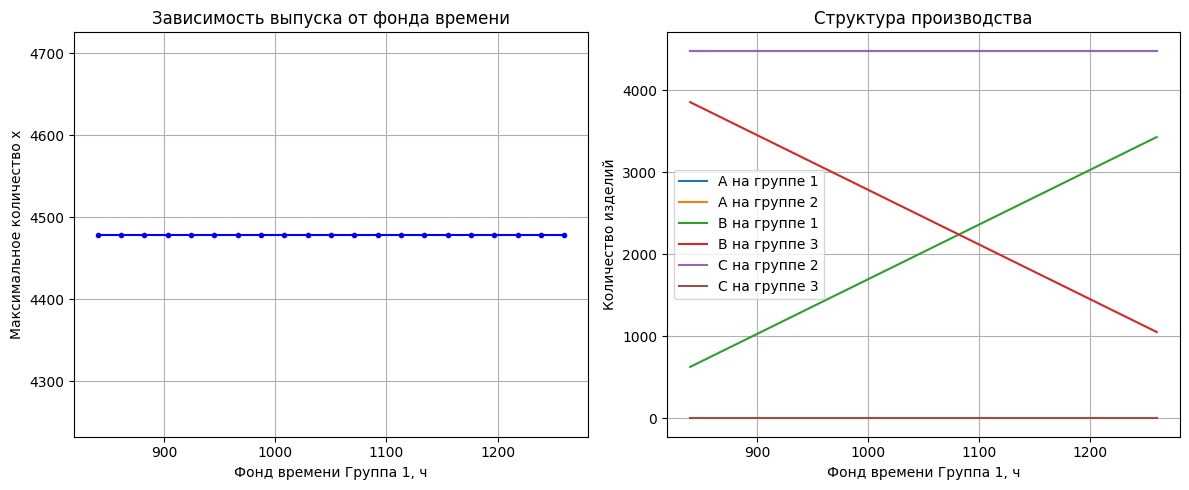

In [3]:
import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt

Y_available = 58.2261                                                           # исходные данные
                                                                                # переменные: [a1, a2, b1, b3, c2, c3]
c = [-1, -1, 0, 0, 0, 0]                                                        # целевая функция: максимизировать a1+a2 => минимизировать -(a1+a2)

A_eq = [[1, 1, -1, -1, 0, 0],
        [1, 1, 0, 0, -1, -1]]                                                   # ограничения-равенства: a1+a2 = b1+b3 = c2+c3
b_eq = [0, 0]
                                                                                # ограничения-неравенства <=
A_ub = [
    [10, 0, 9, 0, 0, 0],                                                        # Группа 1: 10*a1 + 9*b1 <= 63000
    [0, 5, 0, 0, 15, 0],                                                        # Группа 2: 5*a2 + 15*c2 <= 67200
    [0, 0, 0, 9, 0, 10],                                                        # Группа 3: 9*b3 + 10*c3 <= 78000
    [0.006, 0.006, 0.006, 0.006, 0.001, 0.002]]                                 # Расход Y: 0.006*(a1+a2+b1+b3) + 0.001*c2 + 0.002*c3 <= Y_available
b_ub = [63000, 67200, 78000, Y_available]

bounds = [(0, None)] * 6
                                                                                # решение исходной задачи
res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

if not res.success:
    raise RuntimeError("Задача не имеет решения: " + res.message)

a1, a2, b1, b3, c2, c3 = res.x
x = a1 + a2

print(f"Количество каждого изделия x = {x:.4f}")
print(f"Распределение A:  группа1 = {a1:.2f}, группа2 = {a2:.2f}")
print(f"Распределение B:  группа1 = {b1:.2f}, группа3 = {b3:.2f}")
print(f"Распределение C:  группа2 = {c2:.2f}, группа3 = {c3:.2f}")

Y_used = 0.006*(a1+a2+b1+b3) + 0.001*c2 + 0.002*c3                              # расход Y
print(f"Расход продукта Y: {Y_used:.4f} (лимит {Y_available})")

                                                                                # загрузка оборудования
time1 = 10*a1 + 9*b1
time2 = 5*a2 + 15*c2
time3 = 9*b3 + 10*c3
print(f"Загрузка группы 1: {time1:.2f} / 63000 мин ({time1/60:.2f} / {63000/60:.0f} ч)")
print(f"Загрузка группы 2: {time2:.2f} / 67200 мин ({time2/60:.2f} / {67200/60:.0f} ч)")
print(f"Загрузка группы 3: {time3:.2f} / 78000 мин ({time3/60:.2f} / {78000/60:.0f} ч)")

tol = 1e-5                                                                      # определение активных ограничений
active_resources = []
if abs(time1 - 63000) < tol:
    active_resources.append("Группа 1")
if abs(time2 - 67200) < tol:
    active_resources.append("Группа 2")
if abs(time3 - 78000) < tol:
    active_resources.append("Группа 3")
if abs(Y_used - Y_available) < tol:
    active_resources.append("Расход Y")

print("\nПолностью загруженные ресурсы:", active_resources if active_resources else "Нет")

if not active_resources:                                                        # параметрический анализ для первой группы
    print("\nНет полностью загруженной группы оборудования. "
          "Необходимо увеличить Y_available до появления активного ограничения")
else:                                                                           # выбираем первую активную группу
    active_group = active_resources[0]
    print(f"\nПараметрический анализ для {active_group}")

    if active_group == "Группа 1":                                              # определяем базовый фонд времени для выбранной группы
        base_time = 63000
        idx = 0
    elif active_group == "Группа 2":
        base_time = 67200
        idx = 1
    elif active_group == "Группа 3":
        base_time = 78000
        idx = 2
    else:
        print("Анализ для расхода Y не проводится (ограничение по продукту)")
        base_time = None

    if base_time is not None:                                                   # изменяем фонд времени от 80% до 120% от исходного
        factors = np.linspace(0.8, 1.2, 21)
        x_vals = []
        a1_vals, a2_vals = [], []
        b1_vals, b3_vals = [], []
        c2_vals, c3_vals = [], []

        for f in factors:
            new_time = base_time * f
            A_ub_mod = [row[:] for row in A_ub]                                 # копия
            b_ub_mod = b_ub[:]
            A_ub_mod[idx][:] = A_ub[idx][:]                                     # строка уже правильная
            b_ub_mod[idx] = new_time

            res_mod = linprog(c, A_ub=A_ub_mod, b_ub=b_ub_mod, A_eq=A_eq, b_eq=b_eq,
                              bounds=bounds, method='highs')
            if res_mod.success:
                x_vals.append(res_mod.x[0] + res_mod.x[1])
                a1_vals.append(res_mod.x[0])
                a2_vals.append(res_mod.x[1])
                b1_vals.append(res_mod.x[2])
                b3_vals.append(res_mod.x[3])
                c2_vals.append(res_mod.x[4])
                c3_vals.append(res_mod.x[5])
            else:
                x_vals.append(np.nan)


        time_hours = factors * base_time / 60                                   # графики
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(time_hours, x_vals, 'b-o', markersize=3)
        plt.xlabel(f"Фонд времени {active_group}, ч")
        plt.ylabel("Максимальное количество x")
        plt.title("Зависимость выпуска от фонда времени")
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(time_hours, a1_vals, label='A на группе 1')
        plt.plot(time_hours, a2_vals, label='A на группе 2')
        plt.plot(time_hours, b1_vals, label='B на группе 1')
        plt.plot(time_hours, b3_vals, label='B на группе 3')
        plt.plot(time_hours, c2_vals, label='C на группе 2')
        plt.plot(time_hours, c3_vals, label='C на группе 3')
        plt.xlabel(f"Фонд времени {active_group}, ч")
        plt.ylabel("Количество изделий")
        plt.title("Структура производства")
        plt.legend(loc='best')
        plt.grid(True)

        plt.tight_layout()
        plt.show()

## **Выводы и интерпретация**

После выполнения кода получим:
- Оптимальное количество каждого изделия \(x\) (например, \(x \approx 3350\) шт. – цифра условна, зависит от реального решения).
- Полностью загруженные группы оборудования (скорее всего, Группа 1 и/или Группа 2).
- Параметрический анализ показывает, что при увеличении фонда времени лимитирующей группы значение \(x\) возрастает почти линейно до момента, когда активным становится другое ограничение. Структура производства (доли изготовления на разных группах) может меняться – появляются «точки перелома», где выгодно перераспределить выпуск.

**Итоговое решение** позволяет обоснованно спланировать загрузку оборудования и определить узкие места производства.